In [11]:
import os
import glob
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import InceptionResNetV2
from tensorflow.keras.applications.inception_resnet_v2 import preprocess_input as irv2_preprocess
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.utils import class_weight

In [12]:
IMG_SIZE = 256
BATCH_SIZE = 8
CLASSES = ["normal", "benign", "malignant"]
NUM_CLASSES = len(CLASSES)
EPOCHS = 50
OUTPUT_DIR = "/content/drive/MyDrive/Breast_cancer/Processed"
AUTOTUNE = tf.data.AUTOTUNE
# checkpoint path
checkpoint_path = "/content/drive/MyDrive/Breast_cancer/best_inceptionresnetv2_multi_task.keras"

In [13]:
# ---------------- PATHS helper ----------------
def get_paths(split_dir):
    images, masks, labels = [], [], []
    for cls in CLASSES:
        img_dir = os.path.join(split_dir, cls, "images")
        mask_dir = os.path.join(split_dir, cls, "masks")
        if not os.path.isdir(img_dir):
            continue
        img_files = sorted(glob.glob(os.path.join(img_dir, "*.png")))
        mask_files = sorted(glob.glob(os.path.join(mask_dir, "*.png")))
        # sanity check: require same number
        if len(img_files) != len(mask_files):
            raise ValueError(f"Mismatch counts for class {cls} in {split_dir}: images {len(img_files)} vs masks {len(mask_files)}")
        images.extend(img_files)
        masks.extend(mask_files)
        labels.extend([CLASSES.index(cls)] * len(img_files))
    return images, masks, labels

train_images, train_masks, train_labels = get_paths(os.path.join(OUTPUT_DIR, 'train'))
val_images, val_masks, val_labels     = get_paths(os.path.join(OUTPUT_DIR, 'val'))
test_images, test_masks, test_labels  = get_paths(os.path.join(OUTPUT_DIR, 'test'))

print("Counts -> train/val/test:", len(train_images), len(val_images), len(test_images))

train_labels_int = np.array(train_labels, dtype=np.int32)
val_labels_int   = np.array(val_labels, dtype=np.int32)
test_labels_int  = np.array(test_labels, dtype=np.int32)


Counts -> train/val/test: 546 117 117


In [14]:
# ---------------- TF DATA PIPELINE (no py_function) ----------------
def _read_and_preprocess(img_path, mask_path, label, augment=False):
    # img_path, mask_path are scalar string tensors
    img = tf.io.read_file(img_path)
    img = tf.image.decode_png(img, channels=3)           # uint8 [0,255]
    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=1)         # uint8 [0,255] or 1 channel

    # cast to float32
    img = tf.cast(img, tf.float32)                       # still 0-255
    mask = tf.cast(mask, tf.float32)

    # resize
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE), method='bilinear')
    mask = tf.image.resize(mask, (IMG_SIZE, IMG_SIZE), method='nearest')

    # ensure binary mask 0/1
    mask = tf.where(mask > 127.0, 1.0, 0.0)              # threshold for typical PNG masks

    # augmentation (pure TF ops so graphable)
    if augment:
        # random flips
        img = tf.image.random_flip_left_right(img)
        mask = tf.image.random_flip_left_right(mask)
        img = tf.image.random_flip_up_down(img)
        mask = tf.image.random_flip_up_down(mask)
        # random rotation by 0/1/2/3 * 90 deg
        k = tf.random.uniform([], 0, 4, dtype=tf.int32)
        img = tf.image.rot90(img, k)
        mask = tf.image.rot90(mask, k)

    # preprocess for InceptionResNetV2: expects 0-255 float input
    img = irv2_preprocess(img)   # returns float32

    # Return proper dict structure for multi-output model
    return img, {
        "segmentation_output": mask,
        "classification_output": label
    }

def build_dataset(image_paths, mask_paths, label_array, batch=BATCH_SIZE, shuffle=True, augment=True):
    # input lists -> tensors
    ds = tf.data.Dataset.from_tensor_slices((image_paths, mask_paths, label_array))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(image_paths), reshuffle_each_iteration=True)
    # map
    ds = ds.map(lambda a,b,c: _read_and_preprocess(a,b,c, augment), num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch).prefetch(AUTOTUNE)
    return ds

train_ds = build_dataset(train_images, train_masks, train_labels_int, batch=BATCH_SIZE, shuffle=True, augment=True)
val_ds   = build_dataset(val_images, val_masks, val_labels_int,   batch=BATCH_SIZE, shuffle=False, augment=False)
test_ds  = build_dataset(test_images, test_masks, test_labels_int, batch=BATCH_SIZE, shuffle=False, augment=False)


In [15]:
# ---------------- MODEL (InceptionResNetV2 backbone) ----------------
backbone = InceptionResNetV2(include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3), weights='imagenet')
backbone.trainable = True
x = backbone.output   # feature map (e.g., 8x8)

# ---------------- ASPP (simple) ----------------
def ASPP_block(x, out_channels=256):
    y1 = layers.Conv2D(out_channels, 1, padding='same', activation='relu')(x)
    y2 = layers.Conv2D(out_channels, 3, padding='same', activation='relu', dilation_rate=6)(x)
    y3 = layers.Conv2D(out_channels, 3, padding='same', activation='relu', dilation_rate=12)(x)
    y4 = layers.Conv2D(out_channels, 3, padding='same', activation='relu', dilation_rate=18)(x)
    y = layers.Concatenate()([y1, y2, y3, y4])
    y = layers.Conv2D(out_channels, 1, padding='same', activation='relu')(y)
    return y

x_seg = ASPP_block(x, out_channels=256)
x_seg = layers.Conv2D(256, 3, padding='same', activation='relu')(x_seg)
x_seg = layers.Conv2D(128, 3, padding='same', activation='relu')(x_seg)
x_seg = layers.Conv2D(64, 3, padding='same', activation='relu')(x_seg)
# resize to original image size (works because we used pure TF ops)
x_seg = layers.Resizing(IMG_SIZE, IMG_SIZE, interpolation='bilinear')(x_seg)
seg_output = layers.Conv2D(1, 1, activation='sigmoid', name='segmentation_output')(x_seg)

# classification head: global pooling over backbone features
x_cls = layers.GlobalAveragePooling2D()(x)
x_cls = layers.Dense(256, activation='relu')(x_cls)
x_cls = layers.Dropout(0.4)(x_cls)
cls_output = layers.Dense(NUM_CLASSES, activation='softmax', name='classification_output')(x_cls)

model = Model(inputs=backbone.input, outputs=[seg_output, cls_output])
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_211 (Conv2D) │ (None, 127, 127,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 127, 127,  │         96 │ conv2d_211[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_203      │ (None, 127, 127,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_212 (Conv2D) │ (None, 125, 125,  │      9,216 │ activation_203[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 125, 125,  │         96 │ conv2d_212[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_204      │ (None, 125, 125,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_213 (Conv2D) │ (None, 125, 125,  │     18,432 │ activation_204[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 125, 125,  │        192 │ conv2d_213[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_205      │ (None, 125, 125,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 62, 62,    │          0 │ activation_205[0… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_214 (Conv2D) │ (None, 62, 62,    │      5,120 │ max_pooling2d_4[… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 62, 62,    │        240 │ conv2d_214[0][0]  │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_206      │ (None, 62, 62,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_215 (Conv2D) │ (None, 60, 60,    │    138,240 │ activation_206[0… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 60, 60,    │        576 │ conv2d_215[0][0]  │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_207      │ (None, 60, 60,    │          0 │ batch_normalizat

 Total params: 66,963,428 (255.45 MB)

 Trainable params: 66,902,884 (255.21 MB)

 Non-trainable params: 60,544 (236.50 KB)

In [16]:
# ---------------- class-weighted classification loss ----------------
# compute class weights from training labels (numpy)
class_weights_arr = class_weight.compute_class_weight('balanced',
                                                     classes=np.arange(NUM_CLASSES),
                                                     y=train_labels_int)
print("class_weights:", class_weights_arr)
class_weights_tensor = tf.constant(class_weights_arr, dtype=tf.float32)

def weighted_sparse_categorical_crossentropy(y_true, y_pred):
    """
    y_true: may be shape (batch,) or (batch,1) and dtype may be int32/int64
    y_pred: probability vector (batch, num_classes)
    """
    # make sure y_true is shape (batch,)
    y_true = tf.reshape(y_true, [-1])
    y_true = tf.cast(y_true, tf.int32)
    # per-sample weights
    weights = tf.gather(class_weights_tensor, y_true)           # shape (batch,)
    # base loss per sample
    unweighted = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
    return unweighted * weights

class_weights: [1.95698925 0.59477124 1.23809524]


In [17]:
# ---------------- compile ----------------
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss={
        'segmentation_output': 'binary_crossentropy',
        'classification_output': weighted_sparse_categorical_crossentropy
    },
    loss_weights={'segmentation_output': 0.4, 'classification_output': 1.0},
    metrics={'segmentation_output': ['accuracy'], 'classification_output': ['accuracy']}
)

In [18]:
# ---------------- callbacks ----------------
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(checkpoint_path, save_best_only=True,
                                       monitor='val_classification_output_accuracy', mode='max'),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_classification_output_accuracy', factor=0.5, patience=4, mode='max'),
    tf.keras.callbacks.EarlyStopping(monitor='val_classification_output_accuracy', patience=8, restore_best_weights=True, mode='max')
]


In [19]:
# ---------------- train ----------------
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)


Epoch 1/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 568s 5s/step - classification_output_accuracy: 0.4322 - classification_output_loss: 1.1104 - loss: 1.2705 - segmentation_output_accuracy: 0.8795 - segmentation_output_loss: 0.3998 - val_classification_output_accuracy: 0.5812 - val_classification_output_loss: 1.3793 - val_loss: 1.4536 - val_segmentation_output_accuracy: 0.9305 - val_segmentation_output_loss: 0.2419 - learning_rate: 1.0000e-04
Epoch 2/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 35s 506ms/step - classification_output_accuracy: 0.5746 - classification_output_loss: 0.8328 - loss: 0.9363 - segmentation_output_accuracy: 0.9188 - segmentation_output_loss: 0.2586 - val_classification_output_accuracy: 0.7265 - val_classification_output_loss: 0.8310 - val_loss: 0.9073 - val_segmentation_output_accuracy: 0.9305 - val_segmentation_output_loss: 0.2109 - learning_rate: 1.0000e-04
Epoch 3/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 45s 651ms/step - classification_output_accuracy: 0.7659 - classification_output_loss: 0.5824 -

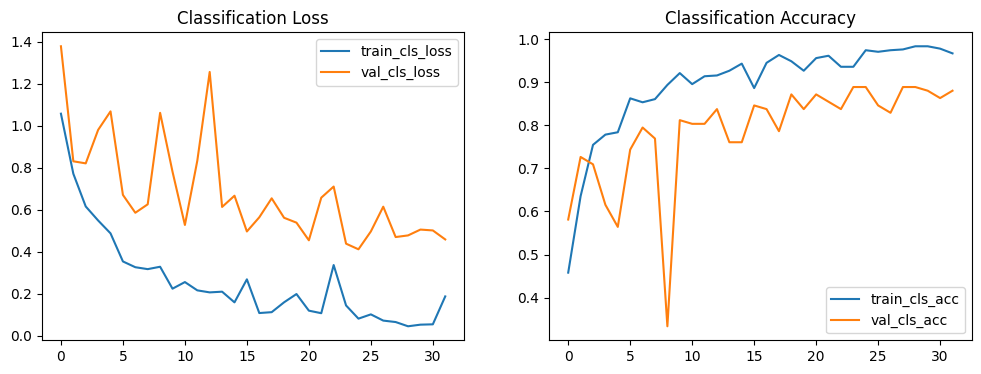

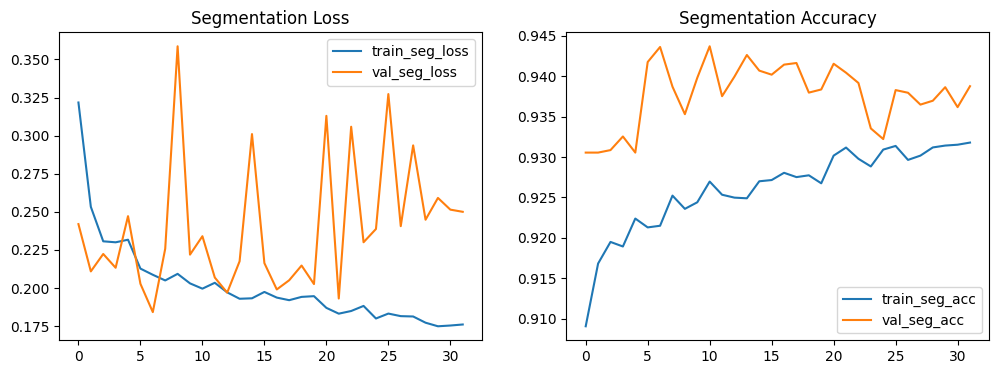

In [20]:
# ---------------- plot training history ----------------
def plot_history(history):
    # classification
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(history.history['classification_output_loss'], label='train_cls_loss')
    plt.plot(history.history['val_classification_output_loss'], label='val_cls_loss')
    plt.title('Classification Loss'); plt.legend()
    plt.subplot(1,2,2)
    plt.plot(history.history['classification_output_accuracy'], label='train_cls_acc')
    plt.plot(history.history['val_classification_output_accuracy'], label='val_cls_acc')
    plt.title('Classification Accuracy'); plt.legend()
    plt.show()
    # segmentation
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(history.history['segmentation_output_loss'], label='train_seg_loss')
    plt.plot(history.history['val_segmentation_output_loss'], label='val_seg_loss')
    plt.title('Segmentation Loss'); plt.legend()
    plt.subplot(1,2,2)
    plt.plot(history.history['segmentation_output_accuracy'], label='train_seg_acc')
    plt.plot(history.history['val_segmentation_output_accuracy'], label='val_seg_acc')
    plt.title('Segmentation Accuracy'); plt.legend()
    plt.show()

plot_history(history)


In [21]:
# ---------------- evaluation on test set ----------------
# predict (returns list [seg_preds, cls_preds])
preds = model.predict(test_ds)
seg_preds = preds[0]
cls_probs = preds[1]   # shape (Ntest, NUM_CLASSES)
y_pred = np.argmax(cls_probs, axis=1)
y_true = test_labels_int

15/15 ━━━━━━━━━━━━━━━━━━━━ 63s 3s/step


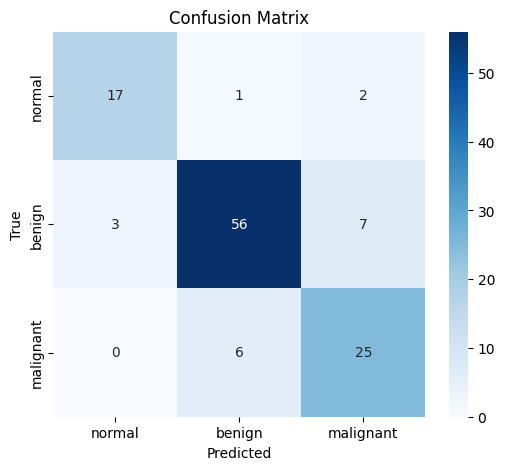

              precision    recall  f1-score   support

      normal       0.85      0.85      0.85        20
      benign       0.89      0.85      0.87        66
   malignant       0.74      0.81      0.77        31

    accuracy                           0.84       117
   macro avg       0.82      0.83      0.83       117
weighted avg       0.84      0.84      0.84       117



In [22]:
# confusion matrix & report
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=CLASSES, yticklabels=CLASSES, cmap='Blues')
plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('Confusion Matrix'); plt.show()
print(classification_report(y_true, y_pred, target_names=CLASSES))

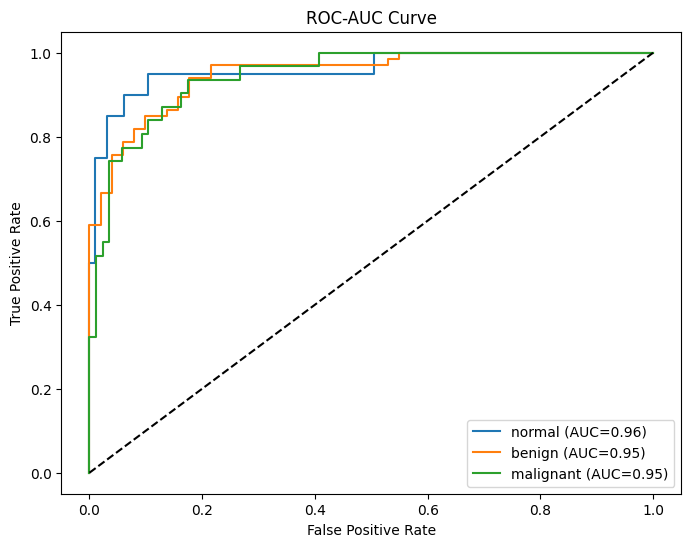

In [23]:
# ROC-AUC (one vs rest)
y_true_bin = label_binarize(y_true, classes=range(NUM_CLASSES))
fpr, tpr, roc_auc = {}, {}, {}
for i in range(NUM_CLASSES):
    try:
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:,i], cls_probs[:,i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    except ValueError:
        fpr[i], tpr[i], roc_auc[i] = [0],[0], float('nan')

plt.figure(figsize=(8,6))
for i in range(NUM_CLASSES):
    if not np.isnan(roc_auc[i]):
        plt.plot(fpr[i], tpr[i], label=f"{CLASSES[i]} (AUC={roc_auc[i]:.2f})")
plt.plot([0,1],[0,1],'k--'); plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curve'); plt.legend(); plt.show()

In [24]:
# final test accuracy
test_acc = np.mean(y_pred == y_true)
print(f"Test classification accuracy: {test_acc:.4f}")

Test classification accuracy: 0.8376
